# Emujin's ML Bootcamp (Lab2)

## Dataset 1 - College Completion
### Model goal: 
predicting the retention rate based on the demographics, aid, and award data of institutions

Target variable - retention rate

### Business metric: 
A high retention rate is good for institution's reputation and results in a higher profit from the business perspective. Being able to predict the retention rate based on the various features of institutions such as financial aid and type of school can help administration of institutions understand what could increase the retention rate. 



In [1]:
# Imports
import pandas as pd
import numpy as np 
#make sure to install sklearn in your terminal first!
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import matplotlib.pyplot as plt

In [120]:
college_dat = pd.read_csv("/workspaces/DS-3021/data/cc_institution_details.csv")

college_dat.info()
college_dat.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3798 entries, 0 to 3797
Data columns (total 63 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   index                                 3798 non-null   int64  
 1   unitid                                3798 non-null   int64  
 2   chronname                             3798 non-null   object 
 3   city                                  3798 non-null   object 
 4   state                                 3798 non-null   object 
 5   level                                 3798 non-null   object 
 6   control                               3798 non-null   object 
 7   basic                                 3798 non-null   object 
 8   hbcu                                  94 non-null     object 
 9   flagship                              50 non-null     object 
 10  long_x                                3798 non-null   float64
 11  lat_y            

,index,unitid,chronname,city,state,level,control,basic,hbcu,flagship,...,vsa_grad_after6_transfer,vsa_grad_elsewhere_after6_transfer,vsa_enroll_after6_transfer,vsa_enroll_elsewhere_after6_transfer,similar,state_sector_ct,carnegie_ct,counted_pct,nicknames,cohort_size
0,0,100654,Alabama A&M University,Normal,Alabama,4-year,Public,Masters Colleges and Universities--larger prog...,X,NaN,...,36.4,5.6,17.2,11.1,232937|100724|405997|113607|139533|144005|2285...,13,386,99.7|07,NaN,882.0
1,1,100663,University of Alabama at Birmingham,Birmingham,Alabama,4-year,Public,Research Universities--very high research acti...,NaN,NaN,...,NaN,NaN,NaN,NaN,196060|180461|201885|145600|209542|236939|1268...,13,106,56.0|07,UAB,1376.0
2,2,100690,Amridge University,Montgomery,Alabama,4-year,Private not-for-profit,Baccalaureate Colleges--Arts & Sciences,NaN,NaN,...,NaN,NaN,NaN,NaN,217925|441511|205124|247825|197647|221856|1353...,16,252,100.0|07,NaN,3.0
3,3,100706,University of Alabama at Huntsville,Huntsville,Alabama,4-year,Public,Research Universities--very high research acti...,NaN,NaN,...,0.0,0.0,0.0,0.0,232186|133881|196103|196413|207388|171128|1900...,13,106,43.1|07,UAH,759.0
4,4,100724,Alabama State University,Montgomery,Alabama,4-year,Public,Masters Colleges and Universities--larger prog...,X,NaN,...,NaN,NaN,NaN,NaN,100654|232937|242617|243197|144005|241739|2354...,13,386,88.0|07,ASU,1351.0


### Cleaning the data

In [182]:
# Drop unnecessary columns
college_dat2 = college_dat.drop(columns=["state", "site", "chronname", "unitid", "city", "basic", "index", "nicknames", "counted_pct", "flagship", "similar", "hbcu", "vsa_enroll_elsewhere_after6_transfer", "vsa_enroll_after6_transfer", "vsa_grad_elsewhere_after6_transfer", "vsa_grad_after6_transfer", "vsa_enroll_elsewhere_after4_transfer", "vsa_enroll_after4_transfer", "vsa_grad_elsewhere_after4_transfer", "vsa_grad_after4_transfer", "vsa_grad_elsewhere_after4_first", "vsa_grad_after4_first", "vsa_year", "vsa_enroll_elsewhere_after6_first", "vsa_enroll_after6_first", "vsa_grad_elsewhere_after6_first", "vsa_grad_after6_first", "vsa_enroll_elsewhere_after4_first", "vsa_enroll_after4_first"]) 

# Convert some columns to category or integer
columns_to_convert_college = ['level', 'control']
college_dat2[columns_to_convert_college]= college_dat2[columns_to_convert_college].astype('category')

# Imputing missing values
numerical_cols = college_dat2.select_dtypes(include=['number']).columns
college_dat2[numerical_cols] = college_dat2[numerical_cols].apply(lambda x: x.fillna(x.median()), axis=0)

In [180]:
# Checked the number of groups in categorical
# For ex: 
print(college_dat2.level.value_counts())

level
4-year    2339
2-year    1459
Name: count, dtype: int64


#### Normalizing the numeric values

In [184]:
college_dat2[numerical_cols] = MinMaxScaler().fit_transform(college_dat2[numerical_cols])
college_dat2.head(2)

,level,control,long_x,lat_y,student_count,awards_per_value,awards_per_state_value,awards_per_natl_value,exp_award_value,exp_award_state_value,...,grad_150_percentile,pell_value,pell_percentile,retain_value,retain_percentile,ft_fac_value,ft_fac_percentile,state_sector_ct,carnegie_ct,cohort_size
0,4-year,Public,0.790292,0.292177,0.023677,0.099927,0.275132,0.306748,0.019941,0.359141,...,0.14,0.712,0.98,0.631,0.17,0.828,0.898990,0.104348,0.746124,0.054289
1,4-year,Public,0.787680,0.267361,0.067476,0.148796,0.275132,0.306748,0.025851,0.359141,...,0.66,0.351,0.39,0.802,0.70,0.924,0.989899,0.104348,0.203488,0.084730


#### One-hot Encoding

In [190]:
categorical_vars_college = list(college_dat2.select_dtypes('category'))

college_dat_1h = pd.get_dummies(college_dat2, columns = categorical_vars_college)

#### Calculating Prevalence

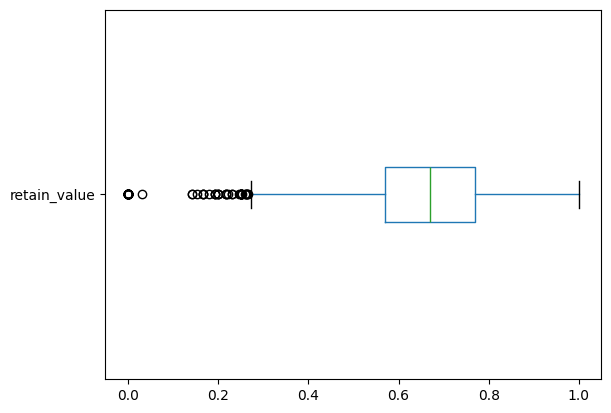

In [212]:
# turning 'retain_value' into a Boolean to be used for classification
# by selecting the top quartile of values

college_dat_1h.boxplot(column='retain_value', vert = False, grid=False)

top_quart_college = college_dat_1h['retain_value'].quantile(0.75)
top_quart_college

college_dat_1h['high_retain_val'] = pd.cut(college_dat_1h['retain_value'], bins = [-1, top_quart_college, 1], labels=[0,1])


Check the prevalence

In [248]:
prevalence_college = college_dat_1h['high_retain_val'].value_counts(normalize=True).get(1, 0)
prevalence_college

np.float64(0.24986835176408637)

### Partitioning (Train, Tune, Test)

In [249]:
Train, Test = train_test_split(college_dat_1h, train_size=2658, stratify=college_dat_1h.high_retain_val)
print(Train.shape)
print(Test.shape)

(2658, 38)
(1140, 38)


In [250]:
Tune, Test = train_test_split(Test, train_size=.5, stratify=Test.high_retain_val)

In [251]:
print(Train.high_retain_val.value_counts())
print(664/(1994+664))

high_retain_val
0    1994
1     664
Name: count, dtype: int64
0.24981188863807374


In [253]:
print(Tune.high_retain_val.value_counts())
print(143/(427+143))

high_retain_val
0    427
1    143
Name: count, dtype: int64
0.25087719298245614


In [255]:
print(Test.high_retain_val.value_counts())
print(142/(428+142))

high_retain_val
0    428
1    142
Name: count, dtype: int64
0.24912280701754386


### Function:

In [ ]:
def preprocess_college_data(url):
    # Read in the college dataset
    college_dat = pd.read_csv(url)
    
    # Drop unnecessary columns
    college_dat2 = college_dat.drop(columns=["state", "site", "chronname", "unitid", "city", "basic", "index", "nicknames", "counted_pct", "flagship", "similar", "hbcu", "vsa_enroll_elsewhere_after6_transfer", "vsa_enroll_after6_transfer", "vsa_grad_elsewhere_after6_transfer", "vsa_grad_after6_transfer", "vsa_enroll_elsewhere_after4_transfer", "vsa_enroll_after4_transfer", "vsa_grad_elsewhere_after4_transfer", "vsa_grad_after4_transfer", "vsa_grad_elsewhere_after4_first", "vsa_grad_after4_first", "vsa_year", "vsa_enroll_elsewhere_after6_first", "vsa_enroll_after6_first", "vsa_grad_elsewhere_after6_first", "vsa_grad_after6_first", "vsa_enroll_elsewhere_after4_first", "vsa_enroll_after4_first"]) 

    # Convert some columns to category
    columns_to_convert_college = ['level', 'control']
    college_dat2[columns_to_convert_college] = college_dat2[columns_to_convert_college].astype('category')

    # Imputing missing values
    numerical_cols = college_dat2.select_dtypes(include=['number']).columns
    college_dat2[numerical_cols] = college_dat2[numerical_cols].apply(lambda x: x.fillna(x.median()), axis=0)

    # Normalizing the numeric values
    college_dat2[numerical_cols] = MinMaxScaler().fit_transform(college_dat2[numerical_cols])

    # One-hot encode categorical variables
    categorical_vars_college = list(college_dat2.select_dtypes('category'))
    college_dat_1h = pd.get_dummies(college_dat2, columns=categorical_vars_college)

    # Turning 'retain_value' into a Boolean to be used for classification
    top_quart_college = college_dat_1h['retain_value'].quantile(0.75)
    college_dat_1h['high_retain_val'] = pd.cut(college_dat_1h['retain_value'], bins=[-1, top_quart_college, 1], labels=[0, 1])

    # Calculate prevalence
    prevalence_college = college_dat_1h['high_retain_val'].value_counts(normalize=True).get(1, 0)

    # Partitioning (Train, Tune, Test)
    Train, Test = train_test_split(college_dat_1h, train_size=2658, stratify=college_dat_1h.high_retain_val)
    Tune, Test = train_test_split(Test, train_size=0.5, stratify=Test.high_retain_val)
    
    return Train, Tune, Test, prevalence_college

url = "/workspaces/DS-3021/data/cc_institution_details.csv"
Train, Tune, Test, prevalence_college = preprocess_college_data(url)

In [256]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score

# Separate features and target variable
X_train1 = Train.drop('high_retain_val', axis=1)
y_train1 = Train['high_retain_val']
X_test1 = Test.drop('high_retain_val', axis=1)
y_test1 = Test['high_retain_val']

# Initialize the DecisionTreeClassifier
dtree1 = DecisionTreeClassifier()

# Fit the model on the training data
dtree1.fit(X_train1, y_train1)

# Predict on the test data
y_pred_dtree1 = dtree1.predict(X_test1)

# Calculate precision
precision1 = precision_score(y_test1, y_pred_dtree1)

print(f'Precision: {precision1}')

Precision: 1.0


## Step 3: 

What do your instincts tell you about the data. Can it address your problem, what areas/items are you worried about? 
- I'm worried that my data is not holistic enough. It focuses a lot on the awards and financial aspect which is only a small part of factors affecting the retention rate. Additionally, a large part of the data was dropped during data cleaning as many columns contained missing values. 
- I also think that regression might have been a better choice for this model since it is predicting the retention rate. Just having groups created by this classification is too broad and doesn't offer a lot of analysis for the businesses. 

## Dataset 2 - Job Placement

## Phase I

### Model goal: 
Predicting a student's salary level based on their academic academic background and work experience.
### Target variable: salary

### Business metric: 
Learning this predicted estimations, school administrations like the SDS can identify what really impacts students' salaries and advise them on landing a high salary job. 

## Phase II

#### Inspecting the data: 

In [3]:
job_dat = pd.read_csv("https://raw.githubusercontent.com/DG1606/CMS-R-2020/master/Placement_Data_Full_Class.csv")

job_dat.info()
job_dat.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sl_no           215 non-null    int64  
 1   gender          215 non-null    object 
 2   ssc_p           215 non-null    float64
 3   ssc_b           215 non-null    object 
 4   hsc_p           215 non-null    float64
 5   hsc_b           215 non-null    object 
 6   hsc_s           215 non-null    object 
 7   degree_p        215 non-null    float64
 8   degree_t        215 non-null    object 
 9   workex          215 non-null    object 
 10  etest_p         215 non-null    float64
 11  specialisation  215 non-null    object 
 12  mba_p           215 non-null    float64
 13  status          215 non-null    object 
 14  salary          148 non-null    float64
dtypes: float64(6), int64(1), object(8)
memory usage: 25.3+ KB


,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.00,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.50,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.00,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.00,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.80,Mkt&Fin,55.50,Placed,425000.0
5,6,M,55.00,Others,49.80,Others,Science,67.25,Sci&Tech,Yes,55.00,Mkt&Fin,51.58,Not Placed,NaN
6,7,F,46.00,Others,49.20,Others,Commerce,79.00,Comm&Mgmt,No,74.28,Mkt&Fin,53.29,Not Placed,NaN
7,8,M,82.00,Central,64.00,Central,Science,66.00,Sci&Tech,Yes,67.00,Mkt&Fin,62.14,Placed,252000.0
8,9,M,73.00,Central,79.00,Central,Commerce,72.00,Comm&Mgmt,No,91.34,Mkt&Fin,61.29,Placed,231000.0
9,10,M,58.00,Central,70.00,Central,Commerce,61.00,Comm&Mgmt,No,54.00,Mkt&Fin,52.21,Not Placed,NaN


#### Cleaning the data:

In [4]:
# Convert some columns to category 
columns_to_convert = ['gender', 'ssc_b', 'hsc_b', 'hsc_s', 'degree_t', 'workex', 'specialisation']
job_dat[columns_to_convert] = job_dat[columns_to_convert].astype('category')

# Drop column "sl_no" since it's just an index, and "status" because it'll be 
# dropped with salary missing values
job_dat1 = job_dat.drop(columns=["sl_no", "status"]) 

# Drop rows with missing values in salary
job_dat2 = job_dat1.dropna(subset=["salary"]) # override job_dat

job_dat2.dtypes

gender            category
ssc_p              float64
ssc_b             category
hsc_p              float64
hsc_b             category
hsc_s             category
degree_p           float64
degree_t          category
workex            category
etest_p            float64
specialisation    category
mba_p              float64
salary             float64
dtype: object

Checking group counts: Everything has less than 5 groups! 

In [5]:
print(job_dat2.ssc_b.value_counts())
print(job_dat2.hsc_b.value_counts())
print(job_dat2.hsc_s.value_counts())
print(job_dat2.degree_t.value_counts())
print(job_dat2.workex.value_counts())
print(job_dat2.specialisation.value_counts())

ssc_b
Central    78
Others     70
Name: count, dtype: int64
hsc_b
Others     91
Central    57
Name: count, dtype: int64
hsc_s
Commerce    79
Science     63
Arts         6
Name: count, dtype: int64
degree_t
Comm&Mgmt    102
Sci&Tech      41
Others         5
Name: count, dtype: int64
workex
No     84
Yes    64
Name: count, dtype: int64
specialisation
Mkt&Fin    95
Mkt&HR     53
Name: count, dtype: int64


#### Scale/Center

In [29]:
# Normalizing the numeric variables

# Manually selected the numeric columns
numerical_vars = ['ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p', 'salary']

job_dat2[numerical_vars] = MinMaxScaler().fit_transform(job_dat2[numerical_vars])

# job_dat2.loc[:, numerical_vars] = StandardScaler().fit_transform(job_dat2[numerical_vars])
job_dat2.head(2)


/tmp/ipykernel_613/984873199.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  job_dat2[numerical_vars] = MinMaxScaler().fit_transform(job_dat2[numerical_vars])


,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,salary
0,M,0.445545,Others,0.857051,Others,Commerce,0.057143,Sci&Tech,No,0.104167,Mkt&HR,0.251666,0.094595
1,M,0.750743,Central,0.586729,Others,Science,0.613714,Sci&Tech,Yes,0.760417,Mkt&Fin,0.544884,0.000000


#### One-hot Encoding

In [237]:
categorical_vars = list(job_dat2.select_dtypes('category'))

job_dat_1h = pd.get_dummies(job_dat2, columns = categorical_vars)

#### Calculating Baseline/Prevalence

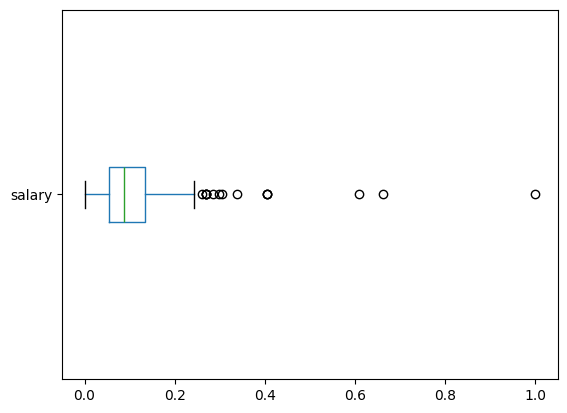

In [238]:
# % is represented by the positive class
# Turning 'salary' into a Boolean to be used for classification
# by selecting the top quartile of values

job_dat_1h.boxplot(column="salary", vert = False, grid = False)
job_dat_1h.salary.describe()

#removing outliers: 
Q1 = job_dat_1h.salary.quantile(0.25)
Q3 = job_dat_1h.salary.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
salary_filtered = job_dat_1h.salary[(job_dat_1h.salary >= lower_bound) & (job_dat_1h.salary <= upper_bound)]

salary_top_quart = salary_filtered.quantile(0.75)
#salary_top_quart = job_dat_1h.salary.quantile(0.75)
# adding this as a predictor
job_dat_1h['salary_high'] = pd.cut(job_dat_1h.salary, bins = [-1, salary_top_quart, 1], labels=[0,1])

Check the prevalence

In [239]:
prevalence = job_dat_1h.salary_high.value_counts()[1]/len(job_dat_1h.salary_high)
prevalence # when I try to decrease the threshold, it becomes 0.33 and there was nowhere in between so leaving it like this

np.float64(0.1891891891891892)

#### Partitioning (Train, Tune, Test)

In [240]:
Train, Test = train_test_split(job_dat_1h, train_size=103, stratify=job_dat_1h.salary_high)
print(Train.shape)
print(Test.shape)

(103, 23)
(45, 23)


In [241]:
Tune, Test = train_test_split(Test, train_size=.5, stratify=Test.salary_high)

In [243]:
print(Train.salary_high.value_counts())
print(19/(84+19))
# this percentage is 18% which is lower than ideal 

salary_high
0    84
1    19
Name: count, dtype: int64
0.18446601941747573


In [245]:
print(Tune.salary_high.value_counts())
print(4/(18+4))

salary_high
0    18
1     4
Name: count, dtype: int64
0.18181818181818182


In [246]:
print(Test.salary_high.value_counts())
print(5/(18+5))

salary_high
0    18
1     5
Name: count, dtype: int64
0.21739130434782608


### Function:

In [117]:
def preprocess_job_data(url):
    # Read in the job dataset
    job_dat = pd.read_csv(url)
    
    # Convert specific columns to category
    columns_to_convert = ['gender', 'ssc_b', 'hsc_b', 'hsc_s', 'degree_t', 'workex', 'specialisation']
    job_dat[columns_to_convert] = job_dat[columns_to_convert].astype('category')
    
    # Drop unnecessary columns: "sl_no" and "status" and assign to a new dataframe
    job_dat1 = job_dat.drop(columns=["sl_no", "status"])
    
    # Drop rows with missing values in salary (essentially only including data from people who could find jobs)
    job_dat2 = job_dat1.dropna(subset=["salary"])
    
    # Normalize the numeric values
    numerical_vars = ['ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p', 'salary']
    job_dat2[numerical_vars] = MinMaxScaler().fit_transform(job_dat2[numerical_vars])
    
    # One-hot encode categorical variables
    categorical_vars = list(job_dat2.select_dtypes('category'))
    job_dat_1h = pd.get_dummies(job_dat2, columns=categorical_vars)
    
    # Removing outliers
    Q1 = job_dat_1h.salary.quantile(0.25)
    Q3 = job_dat_1h.salary.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    salary_filtered = job_dat_1h.salary[(job_dat_1h.salary >= lower_bound) & (job_dat_1h.salary <= upper_bound)]
    
    # Create binary salary column
    salary_top_quart = salary_filtered.quantile(0.75)
    job_dat_1h['salary_high'] = pd.cut(job_dat_1h.salary, bins=[-1, salary_top_quart, 1], labels=[0, 1])
    
    # Calculate prevalence
    prevalence = job_dat_1h.salary_high.value_counts()[1]/len(job_dat_1h.salary_high)


    # Partitioning (Train, Tune, Test)
    Train, Test = train_test_split(job_dat_1h, train_size=55, stratify=job_dat_1h.salary_high)
    Tune, Test = train_test_split(Test, train_size=0.5, stratify=Test.salary_high)
    
    return Train, Tune, Test, prevalence

# Example usage
url = "https://raw.githubusercontent.com/DG1606/CMS-R-2020/master/Placement_Data_Full_Class.csv"
Train, Tune, Test, prevalence

(        ssc_p     hsc_p  degree_p   etest_p     mba_p    salary  gender_F  \
 163  0.346535  0.344997  0.228571  0.520833  0.551940  0.405405     False   
 101  0.346535  0.451675  0.342857  0.583333  0.315955  0.243243     False   
 143  0.709653  0.299979  0.419143  0.812500  0.313995  0.135135     False   
 33   0.940594  0.302326  0.714286  0.791667  0.799686  0.081081      True   
 47   0.346535  0.195648  0.028571  0.583333  0.085065  0.005405     False   
 154  0.099010  0.259654  0.114286  0.416667  0.032144  0.067568     False   
 0    0.445545  0.857051  0.057143  0.104167  0.251666  0.094595     False   
 145  1.000000  0.316407  0.435714  0.458333  0.425323  0.270270     False   
 151  0.396040  0.302326  0.542857  0.687500  0.254410  0.094595     False   
 123  0.618812  0.174312  0.485714  0.208333  0.169345  0.054054     False   
 139  0.693069  0.409004  0.085714  0.166667  0.080361  0.027027     False   
 112  0.222772  0.216983  0.142857  0.166667  0.061152  0.067568

In [226]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score

# Separate features and target variable
X_train = Train.drop('salary_high', axis=1)
y_train = Train['salary_high']
X_test = Test.drop('salary_high', axis=1)
y_test = Test['salary_high']

# Initialize the DecisionTreeClassifier
dtree = DecisionTreeClassifier()

# Fit the model on the training data
dtree.fit(X_train, y_train)

# Predict on the test data
y_pred_dtree = dtree.predict(X_test)

# Calculate precision
precision = precision_score(y_test, y_pred_dtree)

print(f'Precision: {precision}')

Precision: 1.0


## Step 3: 

What do your instincts tell you about the data. Can it address your problem, what areas/items are you worried about? 
- Similar to the Dataset1, this model might have worked better if this was a regression instead of a classification. 
- The threshold for "high salary" is 18% which might be too high and not that insightful for business purposes. 